# Resonator flux spectroscopy

In [1]:
from pathlib import Path

from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.experiments.cal05_resonator_flux_spectroscopy import ResonatorFluxSpectroscopy

## Run parameters

In [2]:
HARDWARE_CONFIG = Path(r"..\config\hw_config.json")
DEVICE_CONFIG = Path(r"..\config\dut_config.json")
FLUX_CONFIG = Path(r"..\config\flux_config.json")   # Flux bias will be restored if not None
OUTPUT_DIR = Path("data")

QUBITS = ["q0"]
FREQUENCY_CENTER = None
FREQUENCY_WIDTH = 30e6
FREQUENCY_POINTS = 201
FLUX_START = -0.5
FLUX_STOP = 0.5
FLUX_POINTS = 51
REPETITIONS = 10
FLUX_SETTLE_TIME = 1e-6

READOUT_AMPLITUDE = None
OUTPUT_ATTENUATION = None
INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True


## Hardware and experiment

In [3]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ResonatorFluxSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Measurement

In [4]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    flux_start=FLUX_START,
    flux_stop=FLUX_STOP,
    flux_points=FLUX_POINTS,
    repetitions=REPETITIONS,
    flux_settle_time=FLUX_SETTLE_TIME,
    readout_amplitude=READOUT_AMPLITUDE,
    output_attenuation=OUTPUT_ATTENUATION,
    input_attenuation=INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

  0%|          | 0/51 [00:00<?, ?step/s]

c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: U

<xarray.Dataset> Size: 410kB
Dimensions:           (acq_index_S21_q0: 10251)
Coordinates:
    flux_q0           (acq_index_S21_q0) float64 82kB -0.5 -0.5 -0.5 ... 0.5 0.5
    frequency_q0      (acq_index_S21_q0) float64 82kB 7.476e+09 ... 7.506e+09
  * acq_index_S21_q0  (acq_index_S21_q0) int64 82kB 0 1 2 ... 10248 10249 10250
Data variables:
    S21_q0            (acq_index_S21_q0) complex128 164kB (0.0229794479131698...
Attributes:
    tuid:     20260811-130439-000-7daa39

## Optional: Simulated data

In [5]:
dataset = experiment.simulated_data(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    flux_start=FLUX_START,
    flux_stop=FLUX_STOP,
    flux_points=FLUX_POINTS,
    maximum_resonance_frequency=None,
    frequency_shift=10e6,
    flux_period=1.0,
    sweet_spot=0.0,
    loaded_quality_factor=1e4,
    coupling_quality_factor=1.2e4,
    noise=0.002,
    seed=42,
)

## Analysis

In [6]:
results = experiment.analysis()

for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: period={result.flux_period:.6g}, "
            f"center={result.center_frequency / 1e9:.9f} GHz"
        )
        for index, value in enumerate(result.sweet_spots):
            print(f"  candidate {index}: {value:.6f} V")
    else:
        print(f"{qubit}: fit failed")

q0: period=1.01594, center=7.485559731 GHz
  candidate 0: -0.000028 V


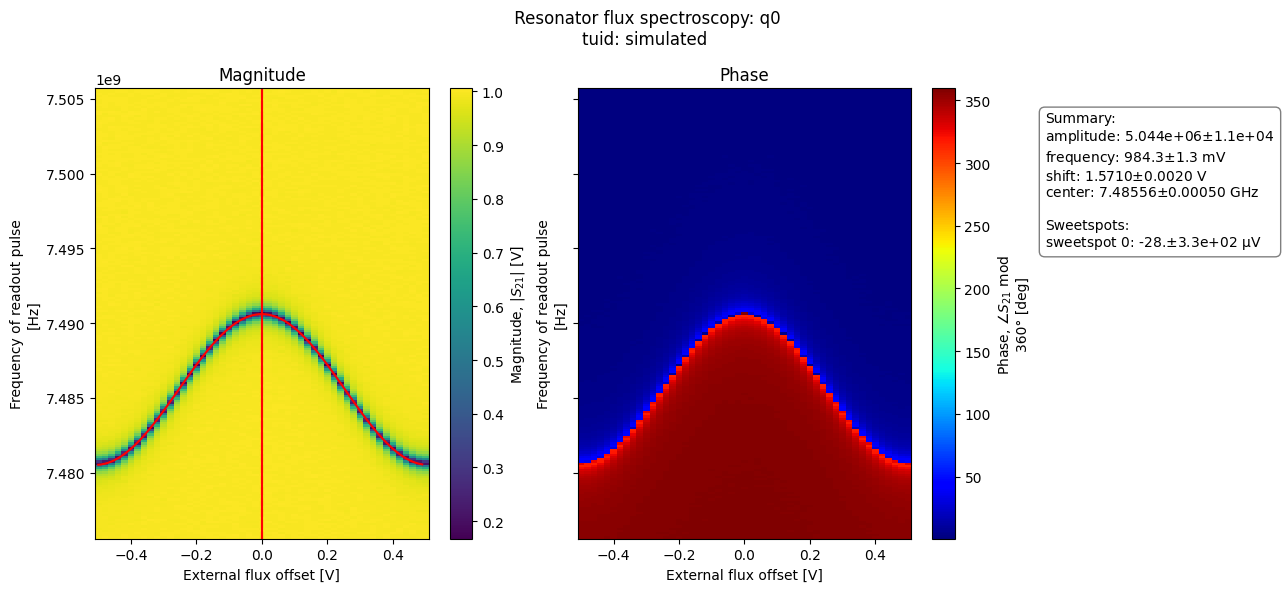

In [7]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: apply and persist a selected operating point

In [20]:
SELECTED_FLUX_BIASES = {"q0": 0.1372}   # Set after inspecting the analysis
APPLY_SELECTED_FLUX_BIASES = True
SAVE_SELECTED_FLUX_BIASES = True

In [21]:
if APPLY_SELECTED_FLUX_BIASES:
    if SELECTED_FLUX_BIASES is None:
        raise ValueError("Set SELECTED_FLUX_BIASES before applying a bias.")

    applied_biases = experiment.apply_flux_biases(SELECTED_FLUX_BIASES)
    for qubit, value in applied_biases.items():
        print(f"{qubit}: live flux bias = {value:.6f} V")

    if SAVE_SELECTED_FLUX_BIASES:
        if FLUX_CONFIG is None:
            raise ValueError("Set FLUX_CONFIG to a file path before saving.")
        saved_path = experiment.save_flux_biases(
            FLUX_CONFIG,
            SELECTED_FLUX_BIASES,
        )
        print(f"Saved flux operating points to {saved_path}")

q0: live flux bias = 0.137191 V
Saved flux operating points to ..\config\flux_config.json
